In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/ultralytics/ultralytics.git
%cd ultralytics
!pip install -e .


Cloning into 'ultralytics'...
remote: Enumerating objects: 108965, done.
remote: Counting objects: 100% (539/539), done.
remote: Compressing objects: 100% (249/249), done.
remote: Total 108965 (delta 411), reused 294 (delta 290), pack-reused 108426 (from 2)
Receiving objects: 100% (108965/108965), 57.15 MiB | 16.89 MiB/s, done.
Resolving deltas: 100% (82442/82442), done.
/content/ultralytics
Obtaining file:///content/ultralytics
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ultralytics (pyproject.toml) ... done
  Created wheel for ultralytics: filename=ultralytics-8.4.98-0.editable-py3-none-any.whl size=23569 sha256=7e5e1de0b55a8c27b65ec71cbc3006ffdcef3d53ba135dcf909d958023583934
  Stored in directory: /tmp/pip-ephem-wheel-cache-92ui_x_y/wheels/60/e0/59/e2f034f296abbdca5c21e3f5be76b9ca685f13c7bd17f8b58c

In [3]:
from ultralytics import YOLO


model = YOLO("yolov8n.pt")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
!yolo train model=yolov8n.pt data=/content/ultralytics/ANPR-1/data.yaml epochs=55 batch=16 imgsz=416


Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ultralytics/ANPR-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=55, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

In [10]:
from IPython.display import Image

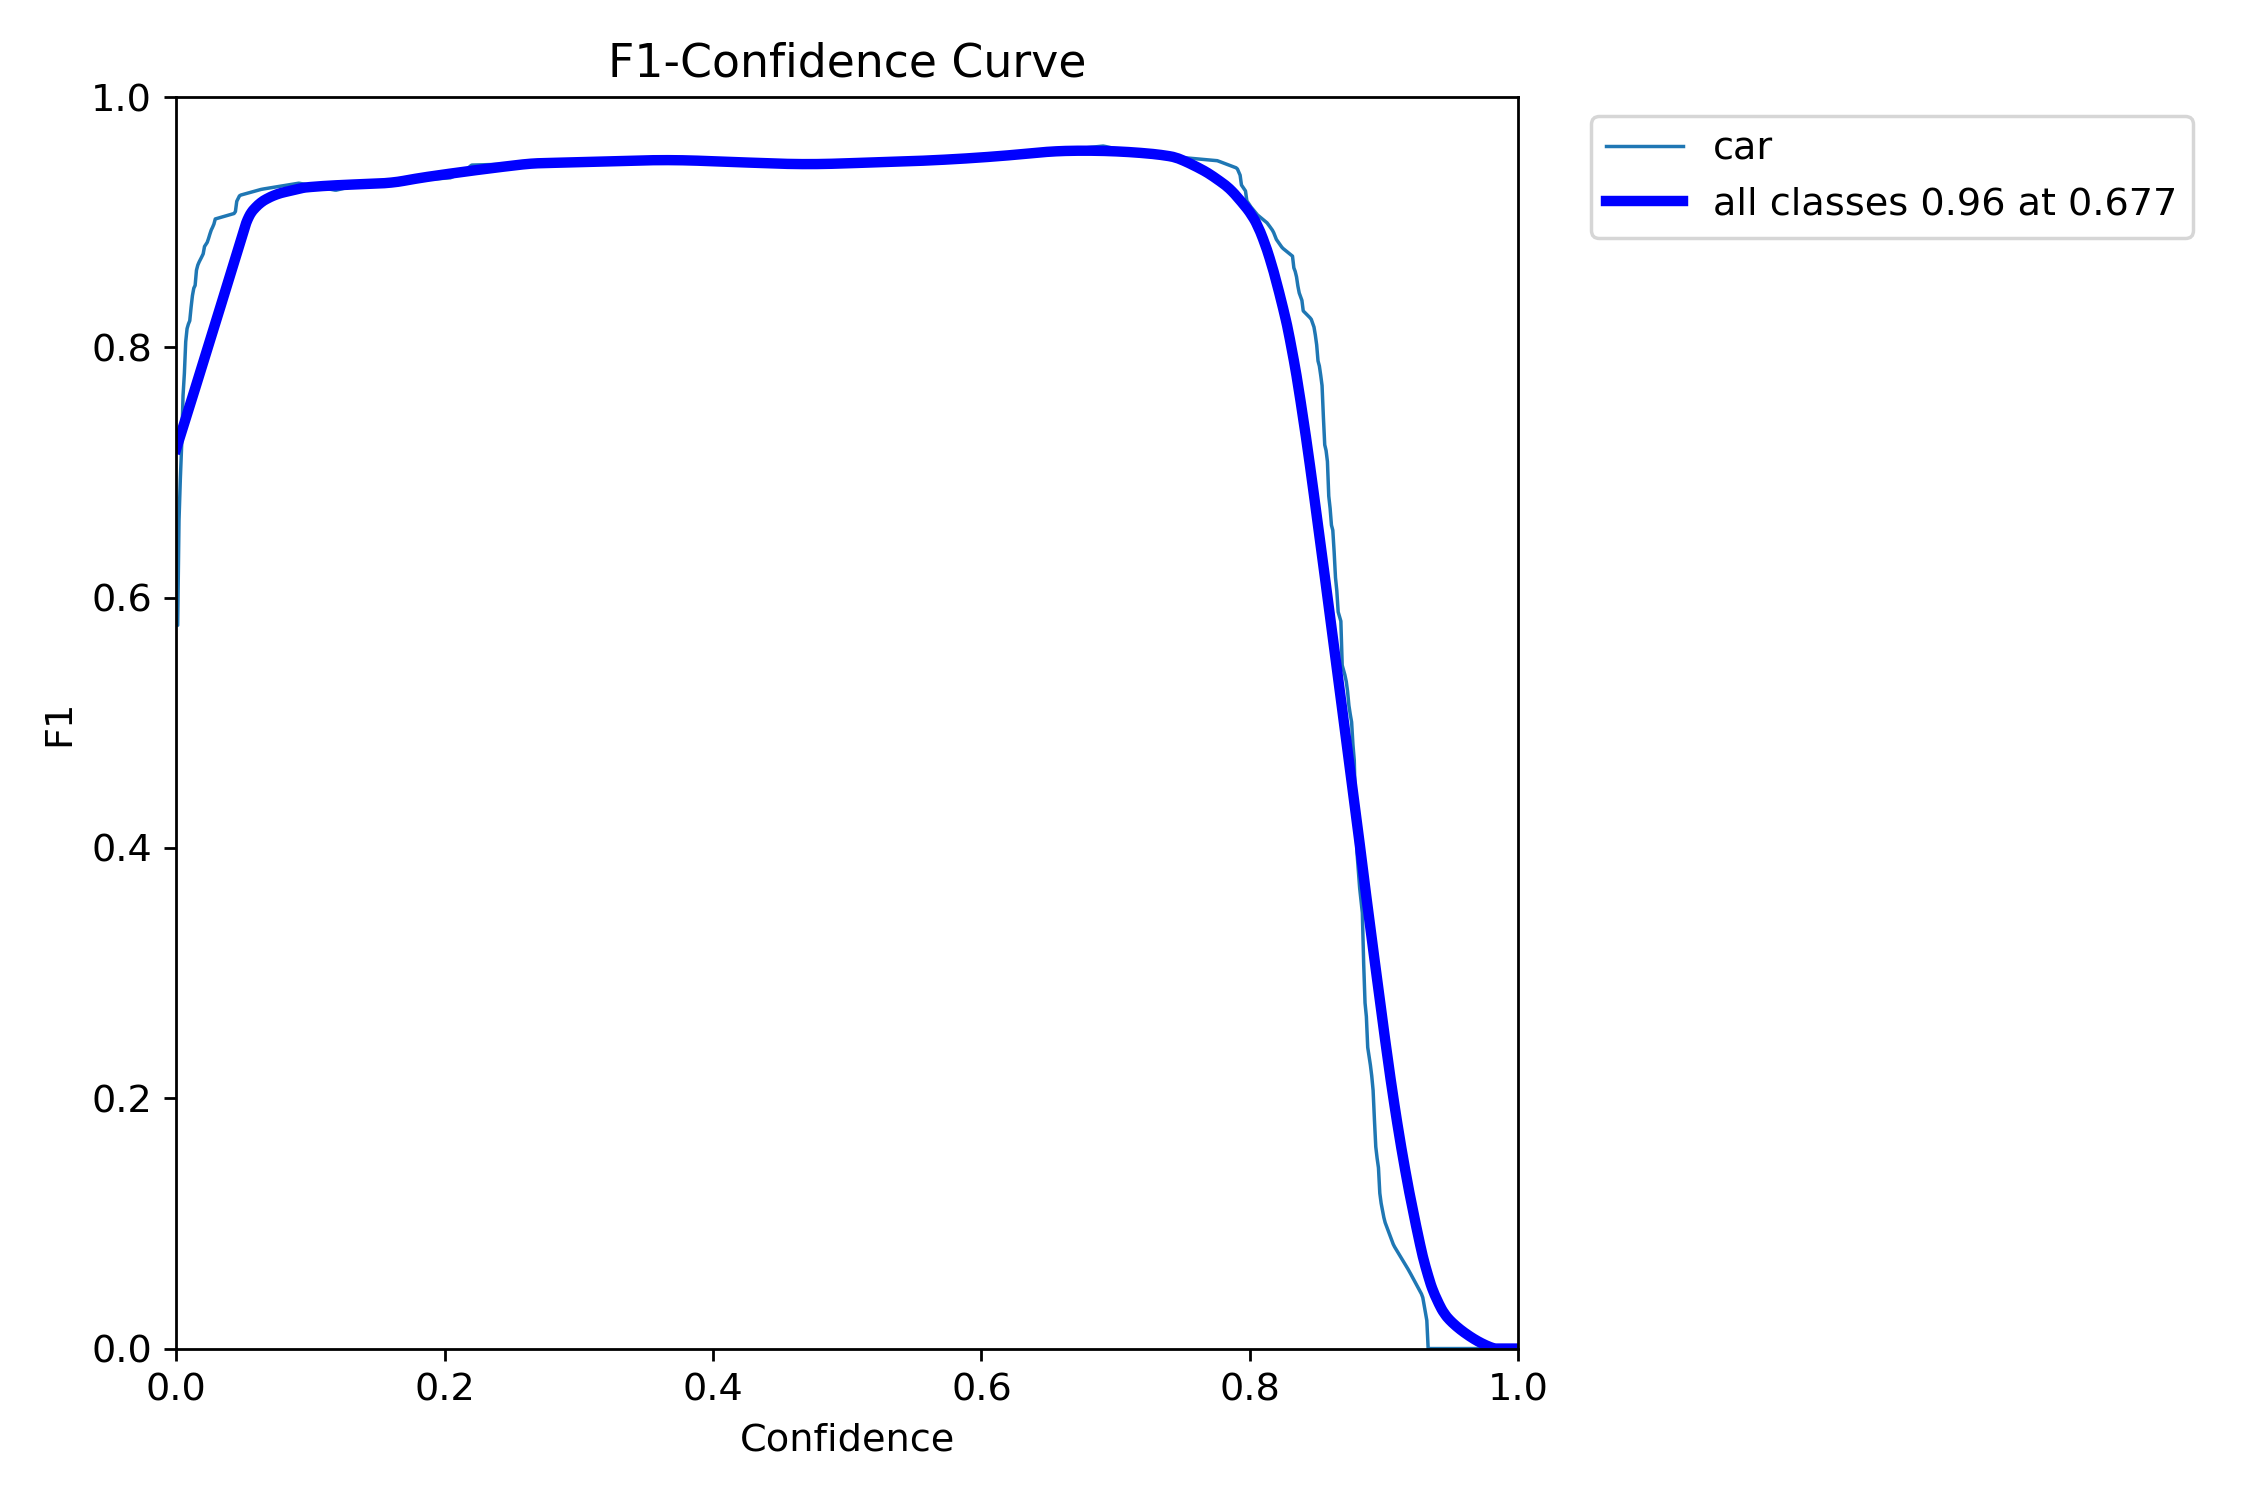

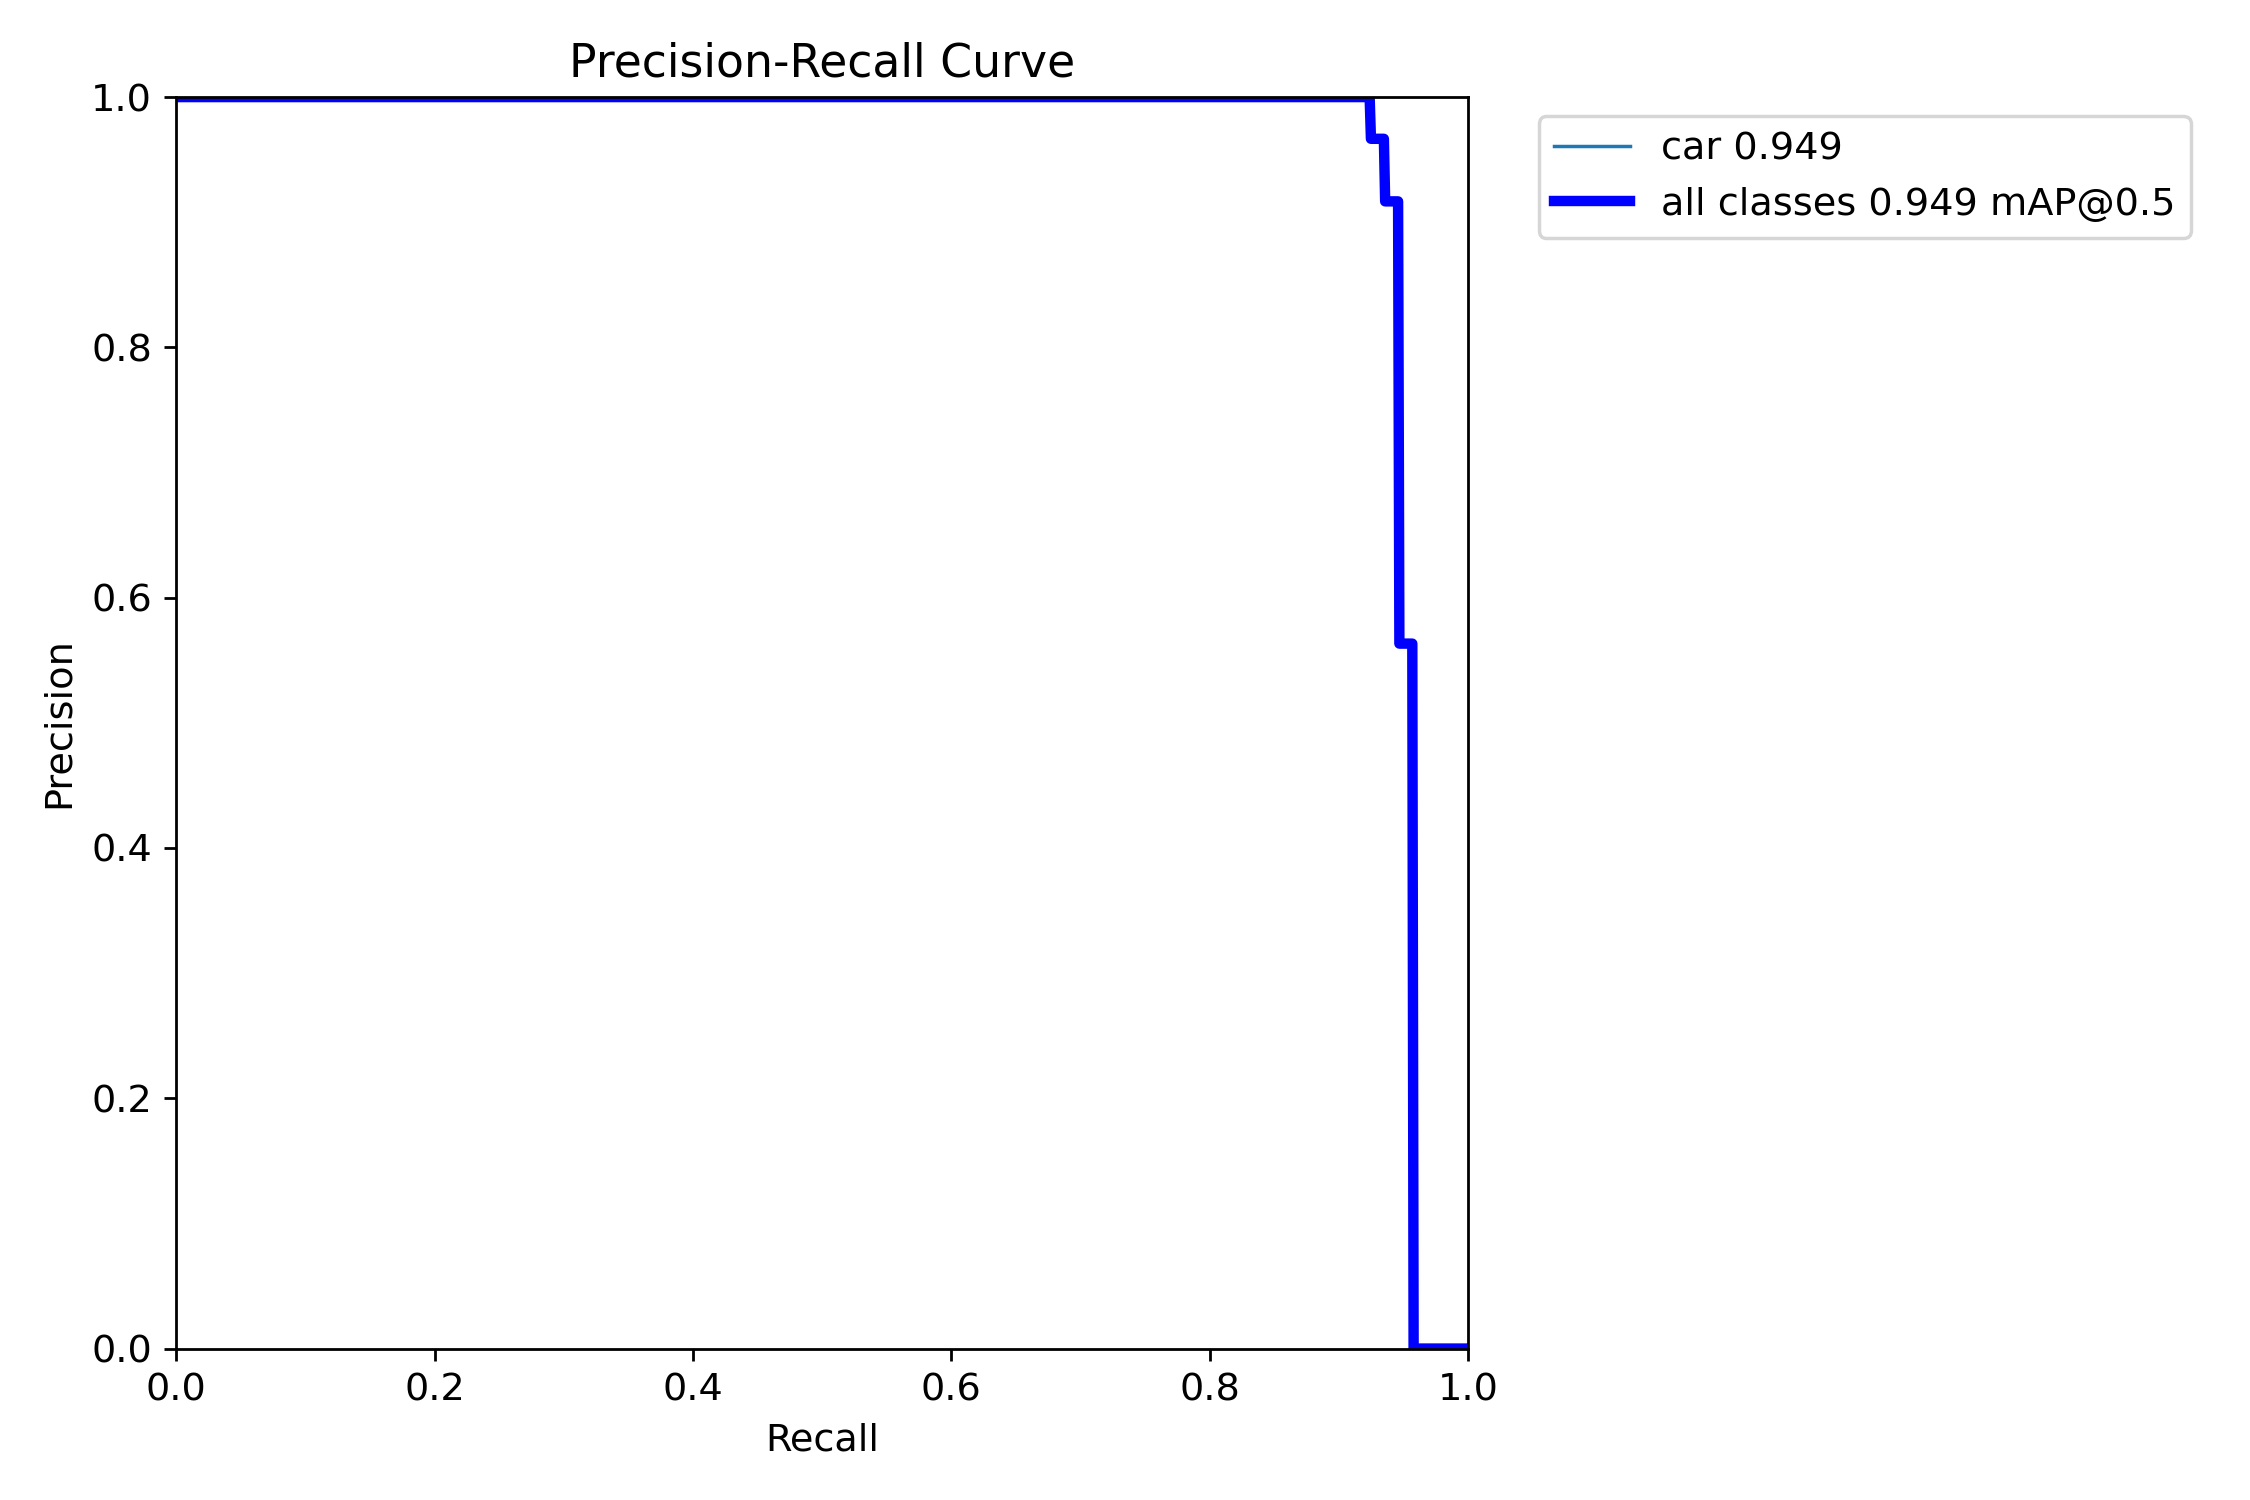

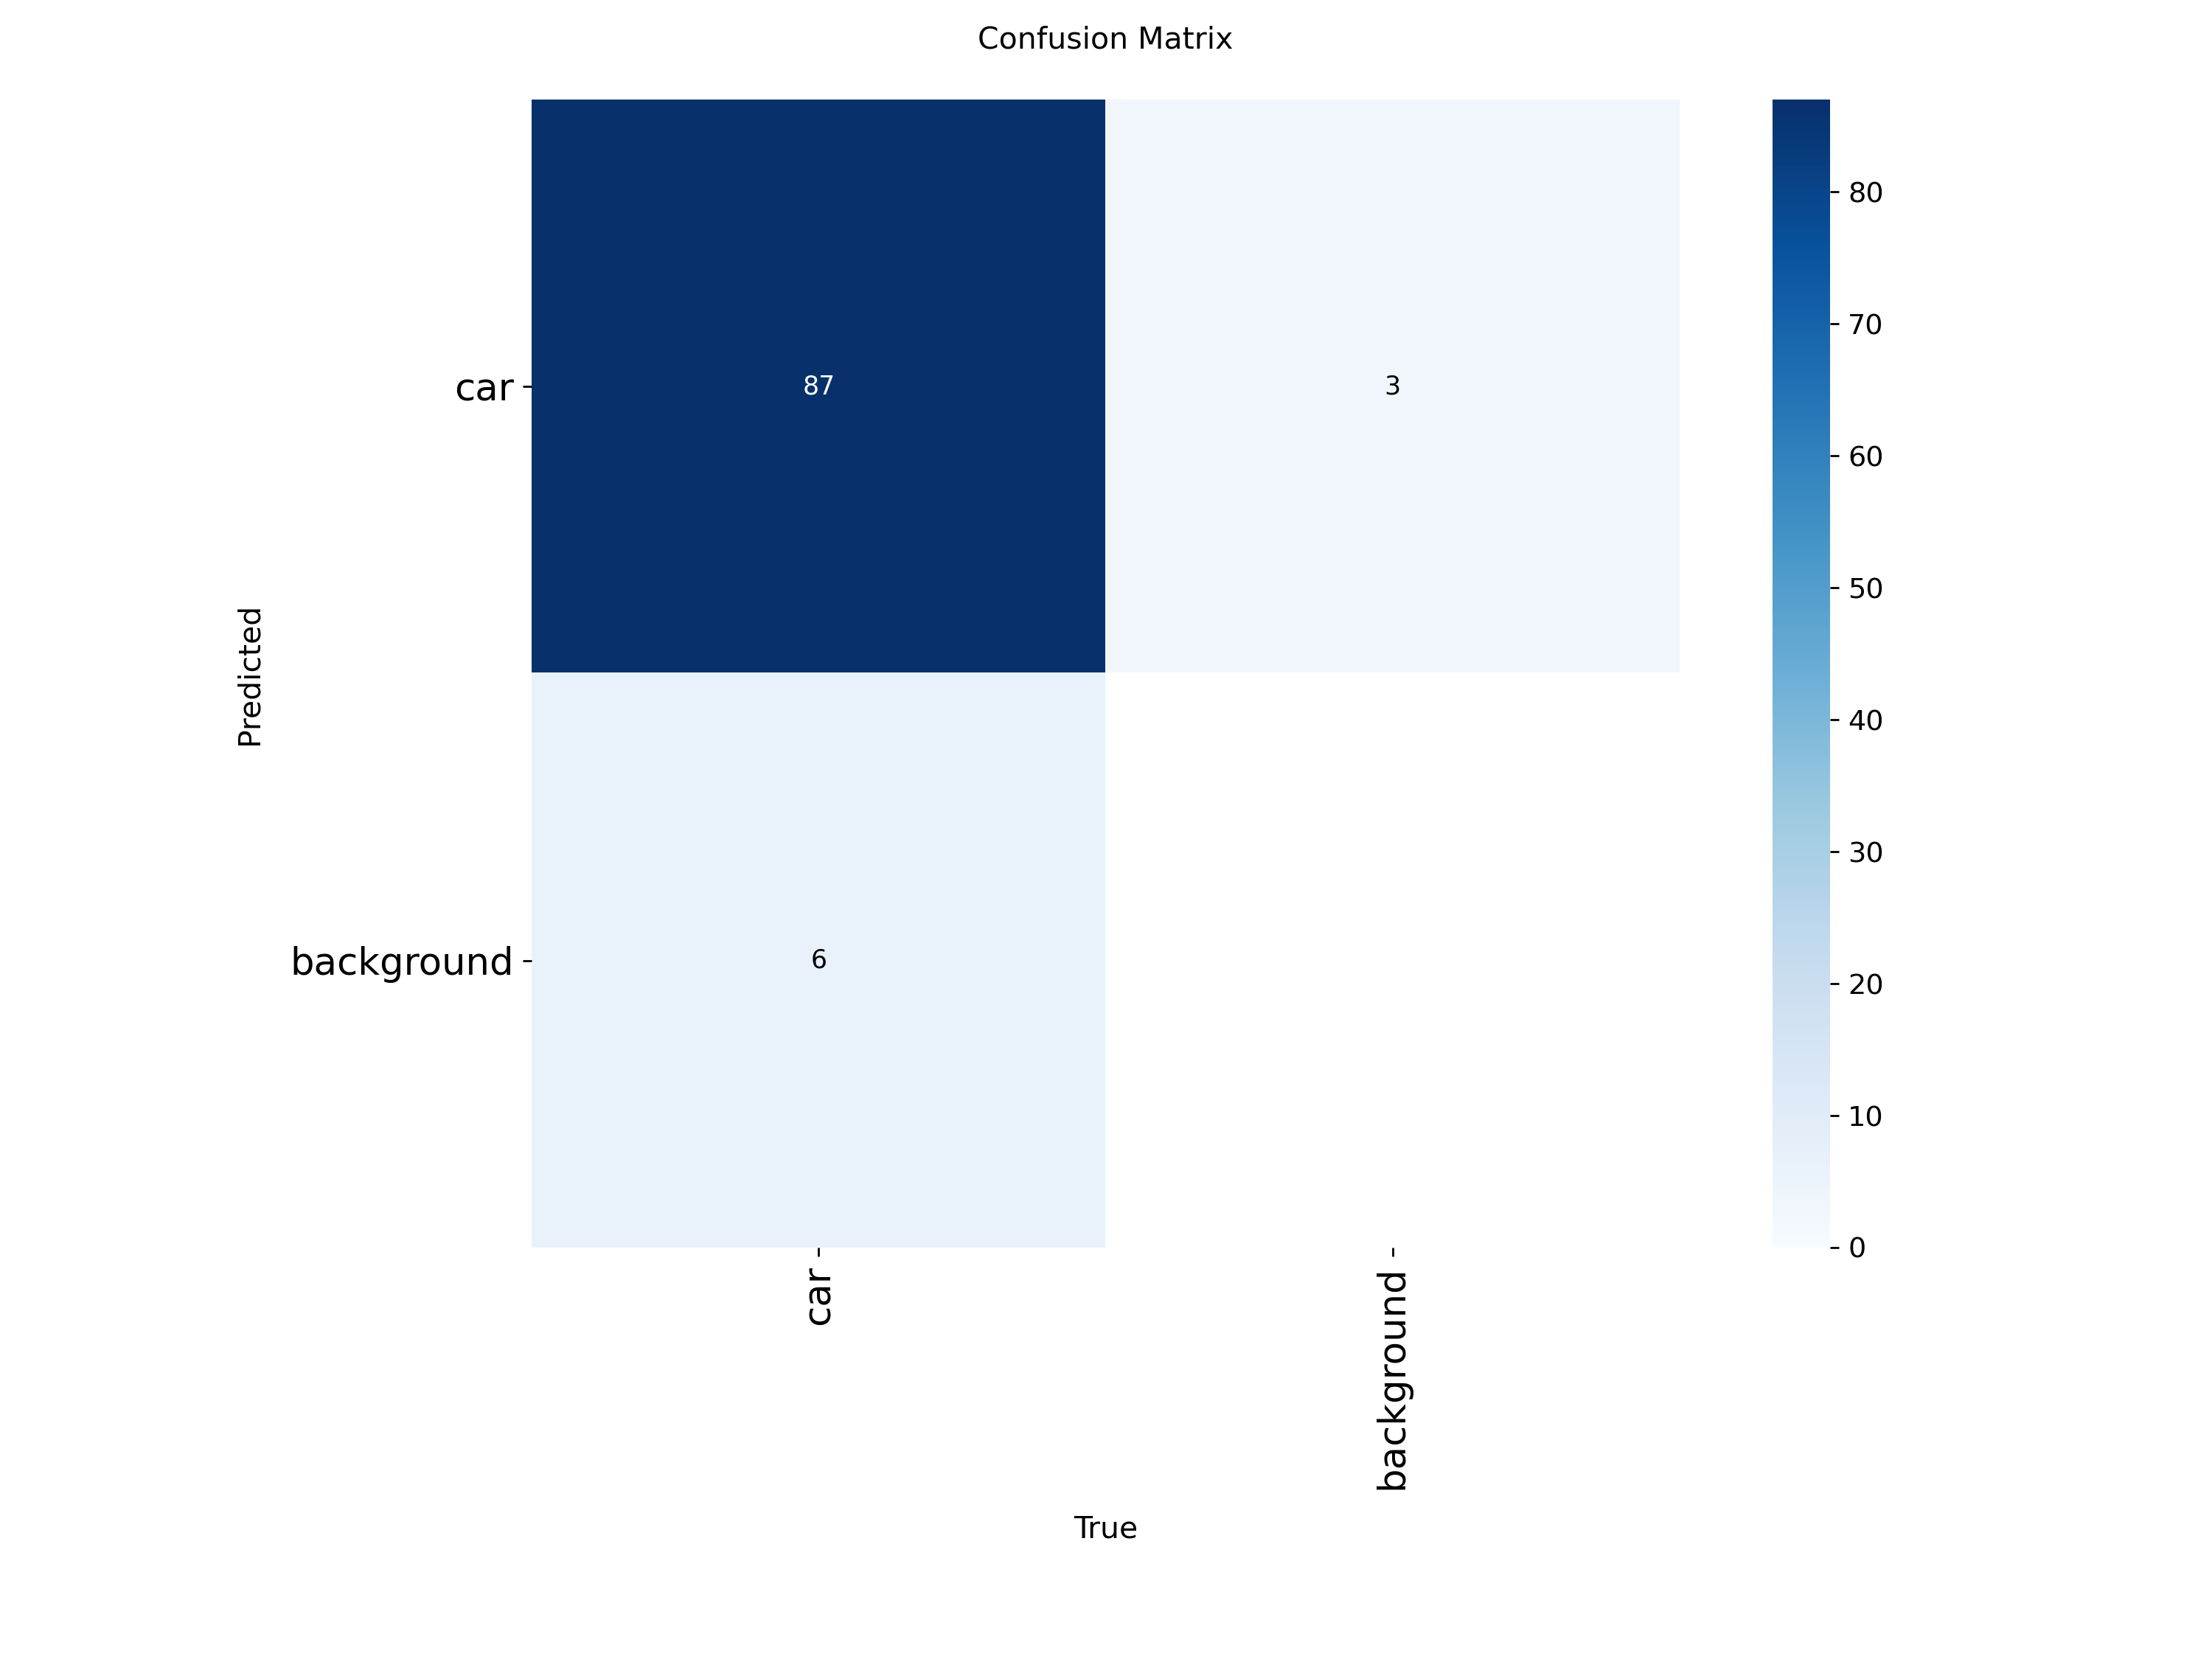

In [11]:
display(Image('/content/ultralytics/runs/detect/train/BoxF1_curve.png', width=400, height=400))
display(Image('/content/ultralytics/runs/detect/train/BoxPR_curve.png', width=400, height=400))
display(Image('/content/ultralytics/runs/detect/train/confusion_matrix.png',width=400, height=400))

In [12]:
!yolo predict model=/content/ultralytics/runs/detect/train/weights/best.pt source=/content/ultralytics/ANPR-1/test/images save=True


Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/44 /content/ultralytics/ANPR-1/test/images/102_jpg.rf.43f97f785c4fbf285967d00e3cb7150e.jpg: 416x416 1 car, 12.4ms
image 2/44 /content/ultralytics/ANPR-1/test/images/141_jpg.rf.c1077ea96dea4fb3f31775c8c57ec607.jpg: 416x416 1 car, 14.8ms
image 3/44 /content/ultralytics/ANPR-1/test/images/142_jpg.rf.50c5426ec246a767693af36e54a9c8da.jpg: 416x416 1 car, 8.0ms
image 4/44 /content/ultralytics/ANPR-1/test/images/148_jpg.rf.0020574b1f2887ad109ff95bb66e2b29.jpg: 416x416 (no detections), 5.9ms
image 5/44 /content/ultralytics/ANPR-1/test/images/156_jpg.rf.c82332bf6bade9995cf96ff41b039407.jpg: 416x416 1 car, 5.9ms
image 6/44 /content/ultralytics/ANPR-1/test/images/193_jpg.rf.9b9c300bf4e4fe007a5a67c43c4b690c.jpg: 416x416 1 car, 5.5ms
image 7/44 /content/ultralytics/ANPR-1/test/images/197_jpg.rf.bcfc63417b27d1d080cb4942194560ba.jpg

Displaying 5 random prediction results:
Displaying: 331_jpg.rf.85a4d4046ee11b725920e7d2943b5974.jpg


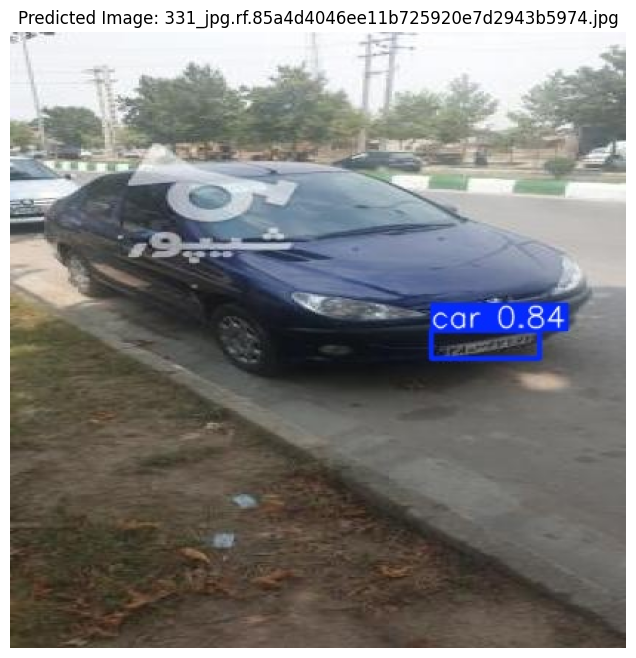

Displaying: 327_jpg.rf.58fc9259ad699f8d340b60f6583a56cd.jpg


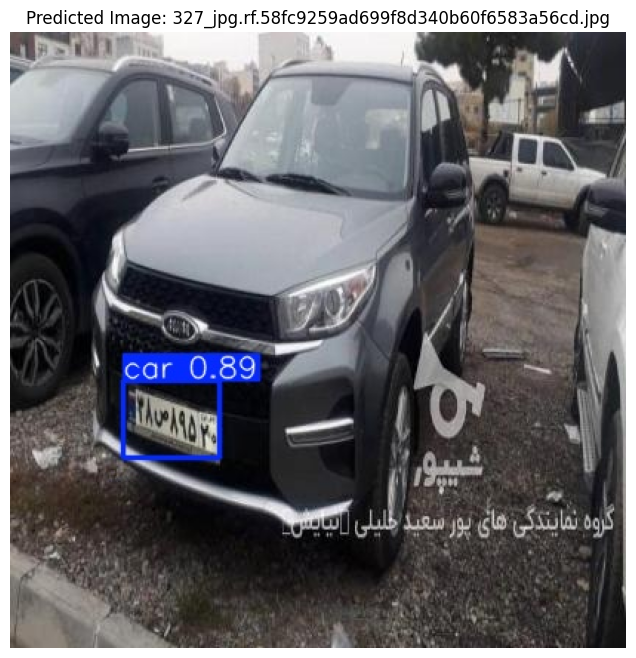

Displaying: 97_jpg.rf.9ee09eed31ce28ee7f0ec8438ace4a99.jpg


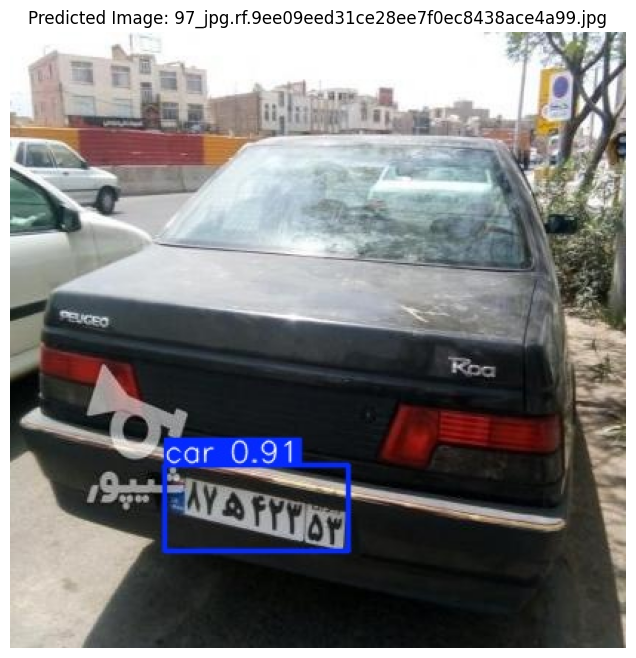

Displaying: 200_jpg.rf.39bfda6b4b1ba647e5211f9ebb1ef690.jpg


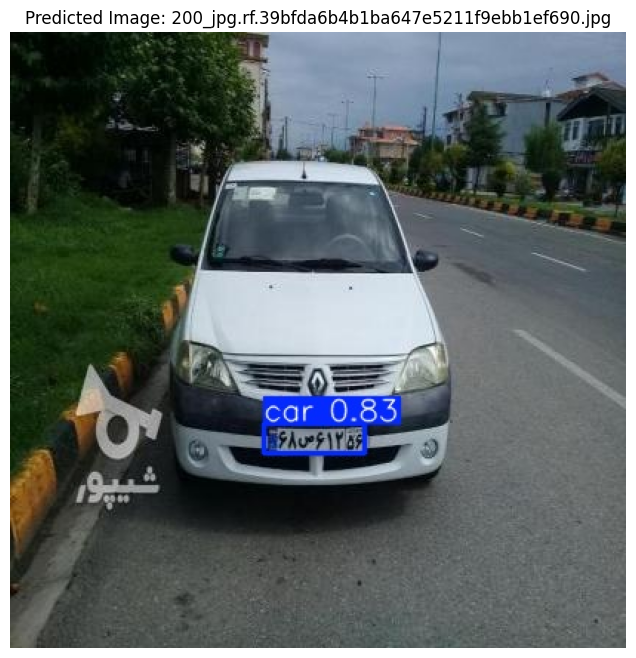

Displaying: 203_jpg.rf.151cdc725b274fd66582379be3c8f037.jpg


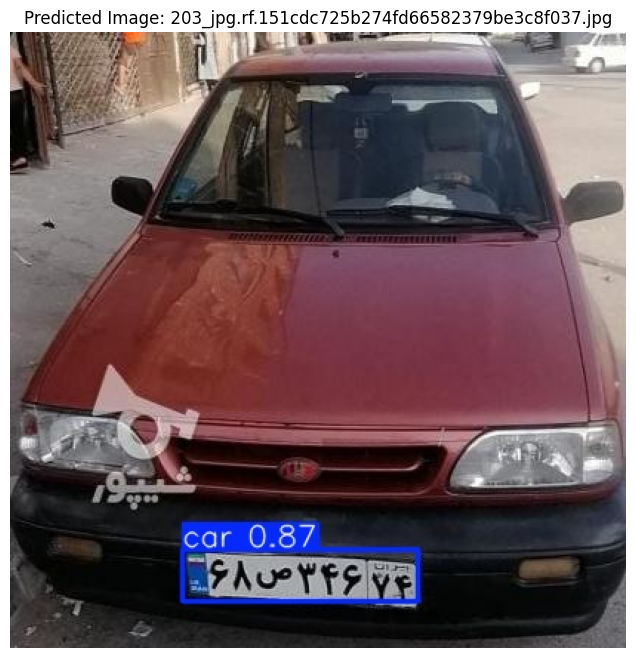

In [14]:
import os
import random
import matplotlib.pyplot as plt
import cv2

# Define the directory where prediction results are saved
prediction_dir = '/content/ultralytics/runs/detect/predict-2'

# Get a list of all image files in the directory
image_files = [f for f in os.listdir(prediction_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Shuffle the list and select a few random images (e.g., 5 images)
random.shuffle(image_files)
selected_images = image_files[:5]

print(f"Displaying {len(selected_images)} random prediction results:")
for img_name in selected_images:
    img_path = os.path.join(prediction_dir, img_name)
    print(f"Displaying: {img_name}")

    # Read the image using OpenCV (which reads in BGR format)
    img = cv2.imread(img_path)

    # Convert BGR image to RGB for matplotlib display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8)) # Adjust figure size as needed
    plt.imshow(img_rgb)
    plt.title(f"Predicted Image: {img_name}")
    plt.axis('off') # Hide axes
    plt.show()
